In [2]:
import pandas as pd
import os

In [3]:
df=pd.read_csv("financial_data_2014-2018.csv")

In [4]:
df.head()

,symbol,year,revenue,revenue_growth,sector,gross_profit,operating_income,operating_expenses,cost_of_revenue
0,PG,2014,7.440100e+10,-0.0713,Consumer Defensive,3.537100e+10,1.391000e+10,2.146100e+10,3.903000e+10
1,VIPS,2014,3.734148e+09,1.1737,Consumer Defensive,9.285226e+08,1.345959e+08,7.939267e+08,2.805625e+09
2,KR,2014,9.837500e+10,0.0182,Consumer Defensive,2.023700e+10,2.725000e+09,1.751200e+10,7.813800e+10
3,RAD,2014,2.552641e+10,0.0053,Consumer Defensive,7.323734e+09,7.372520e+08,6.586482e+09,1.820268e+10
4,GIS,2014,1.790960e+10,0.0076,Consumer Defensive,6.369800e+09,2.957400e+09,3.412400e+09,1.153980e+10


In [5]:
top_companies=(
    df.groupby('symbol')['revenue'].sum().sort_values(ascending=False).head(10).index.tolist()
)
top_companies

['KST', 'WMT', 'SNP', 'PTR', 'XOM', 'BP', 'TM', 'AAPL', 'AMX', 'MCK']

In [6]:
import os

# Get all stock files
available_files = os.listdir("stocks")

# Remove .csv extension
available_symbols = [f.replace('.csv', '') for f in available_files]

# Keep only companies with stock data
valid_companies = [c for c in top_companies if c in available_symbols]

In [7]:
# Select first company from valid list
company = valid_companies[0]

print(company)

WMT


In [8]:
# Load selected company's stock data
stock = pd.read_csv(f"stocks/{company}.csv")

stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1972-08-25,0.063477,0.064697,0.063477,0.064453,0.023442,2508800
1,1972-08-28,0.064453,0.064941,0.064209,0.064209,0.023353,972800
2,1972-08-29,0.063965,0.063965,0.063477,0.063477,0.023087,1945600
3,1972-08-30,0.063477,0.063477,0.062988,0.063477,0.023087,409600
4,1972-08-31,0.062988,0.062988,0.062500,0.062500,0.022732,870400


In [9]:
# Convert column names to lowercase
stock.columns = stock.columns.str.lower()

In [10]:
# Convert date column to datetime format
stock['date'] = pd.to_datetime(stock['date'])

# Extract year from date
stock['year'] = stock['date'].dt.year

# Get first and last closing price for each year
yearly = stock.groupby('year').agg({'close': ['first', 'last']})

In [11]:
yearly.head()

close          
         first      last
year                    
1972  0.064453  0.067383
1973  0.067627  0.026123
1974  0.026611  0.018555
1975  0.019531  0.051270
1976  0.050781  0.060547

In [12]:
yearly.columns = ['first', 'last']  # renaming columns
yearly.head()

,first,last
year,,
1972,0.064453,0.067383
1973,0.067627,0.026123
1974,0.026611,0.018555
1975,0.019531,0.051270
1976,0.050781,0.060547


In [13]:
# Calculate yearly return percentage
yearly['return_pct'] = (
    (yearly['last'] - yearly['first']) / yearly['first']
) * 100

yearly.head()

,first,last,return_pct
year,,,
1972,0.064453,0.067383,4.545455
1973,0.067627,0.026123,-61.371841
1974,0.026611,0.018555,-30.275229
1975,0.019531,0.051270,162.500000
1976,0.050781,0.060547,19.230769


In [14]:
# Keep only years matching financial data
yearly = yearly[(yearly.index >= 2014) & (yearly.index <= 2018)]

yearly

,first,last,return_pct
year,,,
2014,78.910004,85.879997,8.832839
2015,85.900002,61.299999,-28.637953
2016,61.459999,69.120003,12.463397
2017,68.660004,98.750000,43.824635
2018,98.589996,93.150002,-5.517796


In [15]:
# Add company symbol
yearly['symbol'] = company

# Reset index to make year a column
yearly = yearly.reset_index()

yearly.head()

C:\Users\ASHOK SINGH\AppData\Local\Temp\ipykernel_18024\2854305480.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yearly['symbol'] = company


,year,first,last,return_pct,symbol
0,2014,78.910004,85.879997,8.832839,WMT
1,2015,85.900002,61.299999,-28.637953,WMT
2,2016,61.459999,69.120003,12.463397,WMT
3,2017,68.660004,98.750000,43.824635,WMT
4,2018,98.589996,93.150002,-5.517796,WMT


In [16]:
yearly.shape

(5, 5)

In [17]:
# Store yearly returns for all companies
returns_list = []

In [18]:
# Run stock analysis for each company
for company in valid_companies:
    
    # Load stock file
    stock = pd.read_csv(f"stocks/{company}.csv")
    
    # Convert columns to lowercase
    stock.columns = stock.columns.str.lower()
    
    # Convert date format
    stock['date'] = pd.to_datetime(stock['date'])
    
    # Extract year
    stock['year'] = stock['date'].dt.year
    
    # Get yearly first and last closing price
    yearly = stock.groupby('year').agg({'close': ['first', 'last']})
    
    # Rename columns
    yearly.columns = ['first', 'last']
    
    # Calculate yearly return %
    yearly['return_pct'] = (
        (yearly['last'] - yearly['first']) / yearly['first']
    ) * 100
    
    # Keep only 2014–2018
    yearly = yearly[(yearly.index >= 2014) & (yearly.index <= 2018)]
    
    # Add company symbol
    yearly['symbol'] = company
    
    # Reset index
    yearly = yearly.reset_index()
    
    # Save company result
    returns_list.append(yearly)

In [19]:
# Combine all yearly returns
returns_df = pd.concat(returns_list, ignore_index=True)

# Preview combined data
returns_df.head(20)

,year,first,last,return_pct,symbol
0,2014,78.910004,85.879997,8.832839,WMT
1,2015,85.900002,61.299999,-28.637953,WMT
2,2016,61.459999,69.120003,12.463397,WMT
3,2017,68.660004,98.750000,43.824635,WMT
4,2018,98.589996,93.150002,-5.517796,WMT
5,2014,79.930000,81.010002,1.351185,SNP
6,2015,80.209999,59.980000,-25.221294,SNP
7,2016,58.380001,71.019997,21.651242,SNP
8,2017,72.050003,73.370003,1.832061,SNP
9,2018,76.139999,70.599998,-7.276072,SNP


In [20]:
returns_df.shape

(45, 5)

In [21]:
# Merge financial and stock data
merged_df = df.merge(returns_df, on=['symbol', 'year'], how='inner')

# Preview merged data
merged_df.head()

,symbol,year,revenue,revenue_growth,sector,gross_profit,operating_income,operating_expenses,cost_of_revenue,first,last,return_pct
0,WMT,2014,4.762940e+11,0.0163,Consumer Defensive,1.182250e+11,2.687200e+10,9.135300e+10,3.580690e+11,78.910004,85.879997,8.832839
1,MCK,2014,1.373920e+11,0.1244,Healthcare,8.352000e+09,2.439000e+09,5.913000e+09,1.290400e+11,160.160004,207.580002,29.607890
2,TM,2014,2.497173e+11,0.0661,Consumer Cyclical,4.753676e+10,2.227861e+10,2.525815e+10,2.021805e+11,120.629997,125.480003,4.020564
3,AMX,2014,8.482620e+11,0.0000,Communication Services,4.621600e+11,1.565540e+11,3.056050e+11,3.861020e+11,22.650000,22.180000,-2.075052
4,XOM,2014,4.119390e+11,-0.0600,Energy,1.243390e+11,5.191600e+10,7.242300e+10,2.876000e+11,99.750000,92.449997,-7.318299


In [22]:
# Select important columns for analysis
analysis_df = merged_df[['symbol', 'year', 'revenue_growth', 'return_pct']]

# Preview analysis data
analysis_df.head()

,symbol,year,revenue_growth,return_pct
0,WMT,2014,0.0163,8.832839
1,MCK,2014,0.1244,29.607890
2,TM,2014,0.0661,4.020564
3,AMX,2014,0.0000,-2.075052
4,XOM,2014,-0.0600,-7.318299


In [23]:
# Find correlation between revenue growth and stock return
correlation = analysis_df[['revenue_growth', 'return_pct']].corr()

print(correlation)

                revenue_growth  return_pct
revenue_growth        1.000000    0.127981
return_pct            0.127981    1.000000


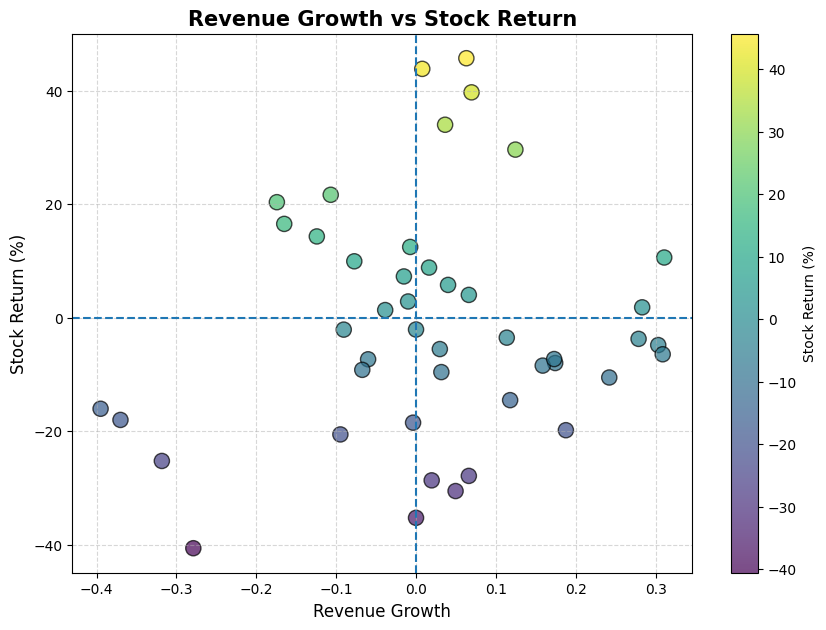

In [24]:
import matplotlib.pyplot as plt

# Create scatter plot with different colors by company

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    analysis_df['revenue_growth'],
    analysis_df['return_pct'],
    c=analysis_df['return_pct'],      # color based on stock return
    s=120,                            # bubble size
    alpha=0.7,                        # transparency
    edgecolors='black'                # border around points
)

# Add color bar
plt.colorbar(scatter, label='Stock Return (%)')

# Labels
plt.xlabel("Revenue Growth", fontsize=12)
plt.ylabel("Stock Return (%)", fontsize=12)
plt.title("Revenue Growth vs Stock Return", fontsize=15, fontweight='bold')

# Grid style
plt.grid(linestyle='--', alpha=0.5)

# Add zero reference lines
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')

plt.show()

In [25]:
# Companies with good revenue growth but poor stock return
undervalued_df = analysis_df[
    (analysis_df['revenue_growth'] > 0) &
    (analysis_df['return_pct'] < 0)
]

undervalued_df.head()

,symbol,year,revenue_growth,return_pct
9,WMT,2015,0.0196,-28.637953
10,MCK,2015,0.3032,-4.811777
17,AAPL,2015,0.2786,-3.722674
19,MCK,2016,0.0661,-27.852264
20,TM,2016,0.1136,-3.507329


In [26]:
# Count how many times company appears undervalued
undervalued_count = undervalued_df['symbol'].value_counts()

undervalued_count

symbol
MCK     3
WMT     2
AAPL    2
TM      2
XOM     2
PTR     2
BP      1
SNP     1
Name: count, dtype: int64

In [27]:
# Company-level summary
undervalued_summary = undervalued_df.groupby('symbol')[
    ['revenue_growth', 'return_pct']
].mean()

undervalued_summary.sort_values(by='revenue_growth', ascending=False)

,revenue_growth,return_pct
symbol,,
BP,0.24190,-10.523839
AAPL,0.21860,-6.075893
PTR,0.21330,-10.474335
XOM,0.18090,-13.890723
SNP,0.17290,-7.276072
MCK,0.13960,-21.062017
TM,0.07265,-6.540606
WMT,0.02470,-17.077875


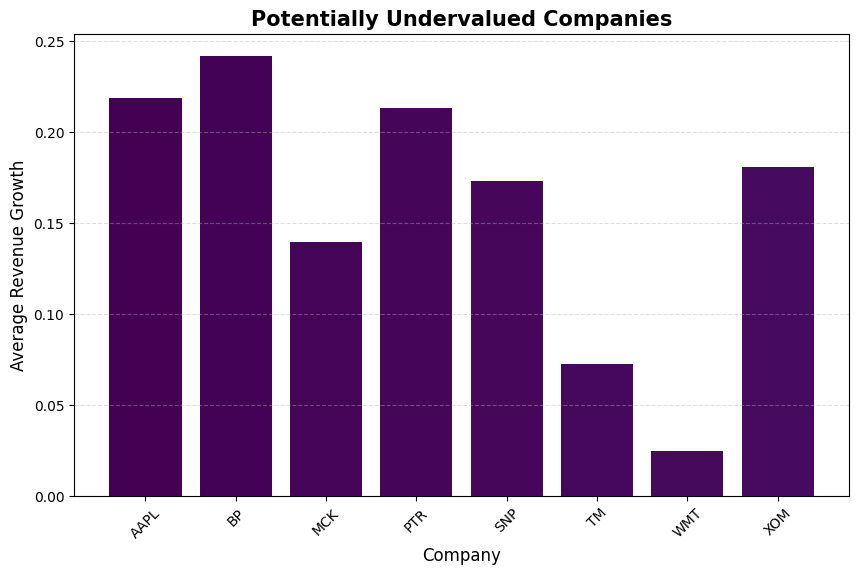

In [28]:
# Attractive gradient color bar chart
plt.figure(figsize=(10,6))

bars = plt.bar(
    undervalued_summary.index,
    undervalued_summary['revenue_growth'],
    color=plt.cm.viridis(
        range(len(undervalued_summary))
    )
)

# Labels
plt.xlabel("Company", fontsize=12)
plt.ylabel("Average Revenue Growth", fontsize=12)
plt.title("Potentially Undervalued Companies", fontsize=15, fontweight='bold')

# Rotate company names
plt.xticks(rotation=45)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [29]:
# Insight:
# Some companies showed positive revenue growth but negative stock returns,
# suggesting potential undervaluation by the market.
# This indicates that strong business performance does not always translate
# into immediate stock price appreciation.
# Investor sentiment, market conditions, and expectations may influence pricing.

In [30]:
# Group data by sector
sector_summary = merged_df.groupby('sector')[
    ['revenue_growth', 'return_pct']
].mean()

sector_summary

,revenue_growth,return_pct
sector,,
Communication Services,-0.006920,-6.196492
Consumer Cyclical,0.021140,-0.776448
Consumer Defensive,0.013240,6.193024
Energy,-0.016915,-5.237016
Healthcare,0.116660,-5.559829
Technology,0.098480,16.634943


In [31]:
# Sort sectors by stock return
sector_summary = sector_summary.sort_values(
    by='return_pct',
    ascending=False
)

sector_summary

,revenue_growth,return_pct
sector,,
Technology,0.098480,16.634943
Consumer Defensive,0.013240,6.193024
Consumer Cyclical,0.021140,-0.776448
Energy,-0.016915,-5.237016
Healthcare,0.116660,-5.559829
Communication Services,-0.006920,-6.196492


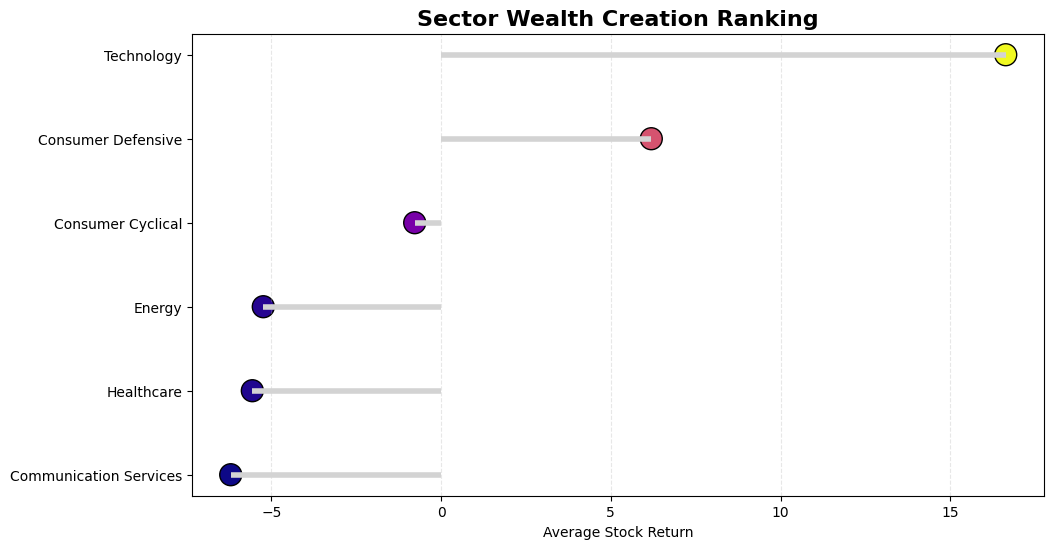

In [32]:
import matplotlib.pyplot as plt

# Sort sectors by stock return
sector_sorted = sector_summary.sort_values('return_pct')

# Create figure
plt.figure(figsize=(11,6))

# Draw lines
plt.hlines(
    y=sector_sorted.index,
    xmin=0,
    xmax=sector_sorted['return_pct'],
    color='lightgray',
    linewidth=4
)

# Draw dots
plt.scatter(
    sector_sorted['return_pct'],
    sector_sorted.index,
    s=250,
    c=sector_sorted['return_pct'],
    cmap='plasma',
    edgecolors='black'
)

# Labels
plt.xlabel("Average Stock Return")
plt.title("Sector Wealth Creation Ranking", fontsize=16, fontweight='bold')

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

In [33]:
# Insight:
# Technology emerged as the strongest wealth-creating sector,
# showing the highest average stock return.
# Consumer Defensive also delivered positive returns,
# indicating relatively stable sector performance.
# Energy, Healthcare, and Communication Services showed weaker returns,
# suggesting sector trends significantly influence long-term investment outcomes.

In [34]:
# Average return for each sector
sector_avg = merged_df.groupby('sector')['return_pct'].mean()

sector_avg

sector
Communication Services    -6.196492
Consumer Cyclical         -0.776448
Consumer Defensive         6.193024
Energy                    -5.237016
Healthcare                -5.559829
Technology                16.634943
Name: return_pct, dtype: float64

In [35]:
# Average return for each company
company_avg = merged_df.groupby(['symbol', 'sector'])['return_pct'].mean().reset_index()

company_avg.head()

,symbol,sector,return_pct
0,AAPL,Technology,16.634943
1,AMX,Communication Services,-6.196492
2,BP,Energy,-3.623378
3,MCK,Healthcare,-5.559829
4,PTR,Energy,-8.871231


In [36]:
# Merge sector average with company average
company_vs_sector = company_avg.merge(
    sector_avg,
    on='sector',
    suffixes=('_company', '_sector')
)

company_vs_sector.head()

,symbol,sector,return_pct_company,return_pct_sector
0,AAPL,Technology,16.634943,16.634943
1,AMX,Communication Services,-6.196492,-6.196492
2,BP,Energy,-3.623378,-5.237016
3,MCK,Healthcare,-5.559829,-5.559829
4,PTR,Energy,-8.871231,-5.237016


In [37]:
# Difference between company and sector
company_vs_sector['outperformance'] = (
    company_vs_sector['return_pct_company']
    - company_vs_sector['return_pct_sector']
)

company_vs_sector.head()

,symbol,sector,return_pct_company,return_pct_sector,outperformance
0,AAPL,Technology,16.634943,16.634943,0.000000
1,AMX,Communication Services,-6.196492,-6.196492,0.000000
2,BP,Energy,-3.623378,-5.237016,1.613638
3,MCK,Healthcare,-5.559829,-5.559829,0.000000
4,PTR,Energy,-8.871231,-5.237016,-3.634216


In [38]:
# Best outperforming companies
company_vs_sector.sort_values(
    by='outperformance',
    ascending=False
)

,symbol,sector,return_pct_company,return_pct_sector,outperformance
5,SNP,Energy,-1.532576,-5.237016,3.704440
2,BP,Energy,-3.623378,-5.237016,1.613638
0,AAPL,Technology,16.634943,16.634943,0.000000
3,MCK,Healthcare,-5.559829,-5.559829,0.000000
1,AMX,Communication Services,-6.196492,-6.196492,0.000000
7,WMT,Consumer Defensive,6.193024,6.193024,0.000000
6,TM,Consumer Cyclical,-0.776448,-0.776448,0.000000
8,XOM,Energy,-6.920878,-5.237016,-1.683862
4,PTR,Energy,-8.871231,-5.237016,-3.634216


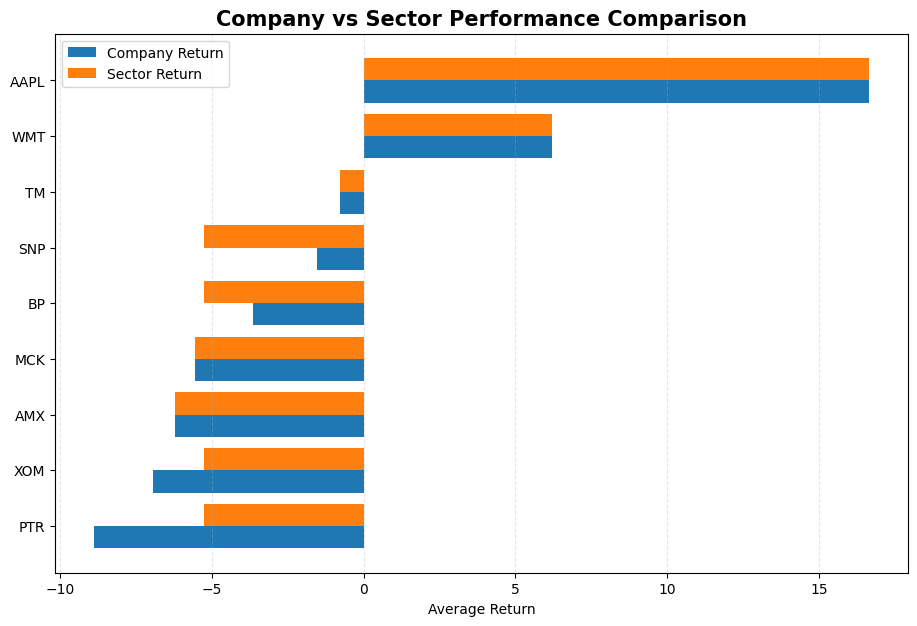

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Sort data
plot_df = company_vs_sector.sort_values('return_pct_company')

# Positions
y = np.arange(len(plot_df))

plt.figure(figsize=(11,7))

# Company bars
plt.barh(
    y - 0.2,
    plot_df['return_pct_company'],
    height=0.4,
    label='Company Return'
)

# Sector bars
plt.barh(
    y + 0.2,
    plot_df['return_pct_sector'],
    height=0.4,
    label='Sector Return'
)

# Labels
plt.yticks(y, plot_df['symbol'])

plt.xlabel("Average Return")
plt.title("Company vs Sector Performance Comparison", fontsize=15, fontweight='bold')

# Legend
plt.legend()

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

In [40]:
# Insight:
# Company performance is influenced by both sector trends and individual company strength.
# Some companies closely mirrored sector performance,
# while others significantly outperformed or underperformed their industry average.
# This suggests that sector conditions matter,
# but company-specific performance also plays a major role in investment outcomes.

In [41]:
# Sort data by company and year
analysis_df = analysis_df.sort_values(
    by=['symbol', 'year']
)

analysis_df.head()

,symbol,year,revenue_growth,return_pct
8,AAPL,2014,0.0695,39.688680
17,AAPL,2015,0.2786,-3.722674
26,AAPL,2016,-0.0773,9.938302
35,AAPL,2017,0.0630,45.699521
36,AAPL,2018,0.1586,-8.429113


In [42]:
# Shift stock returns upward for each company
analysis_df['next_year_return'] = analysis_df.groupby(
    'symbol'
)['return_pct'].shift(-1)

analysis_df.head()

,symbol,year,revenue_growth,return_pct,next_year_return
8,AAPL,2014,0.0695,39.688680,-3.722674
17,AAPL,2015,0.2786,-3.722674,9.938302
26,AAPL,2016,-0.0773,9.938302,45.699521
35,AAPL,2017,0.0630,45.699521,-8.429113
36,AAPL,2018,0.1586,-8.429113,NaN


In [43]:
# Remove rows with missing next year return
analysis_df = analysis_df.dropna(subset=['next_year_return'])

analysis_df.head()

,symbol,year,revenue_growth,return_pct,next_year_return
8,AAPL,2014,0.0695,39.688680,-3.722674
17,AAPL,2015,0.2786,-3.722674,9.938302
26,AAPL,2016,-0.0773,9.938302,45.699521
35,AAPL,2017,0.0630,45.699521,-8.429113
3,AMX,2014,0.0000,-2.075052,-35.237213


In [44]:
# Correlation between revenue growth and future stock return
analysis_df[
    ['revenue_growth', 'next_year_return']
].corr()

,revenue_growth,next_year_return
revenue_growth,1.000000,-0.376098
next_year_return,-0.376098,1.000000


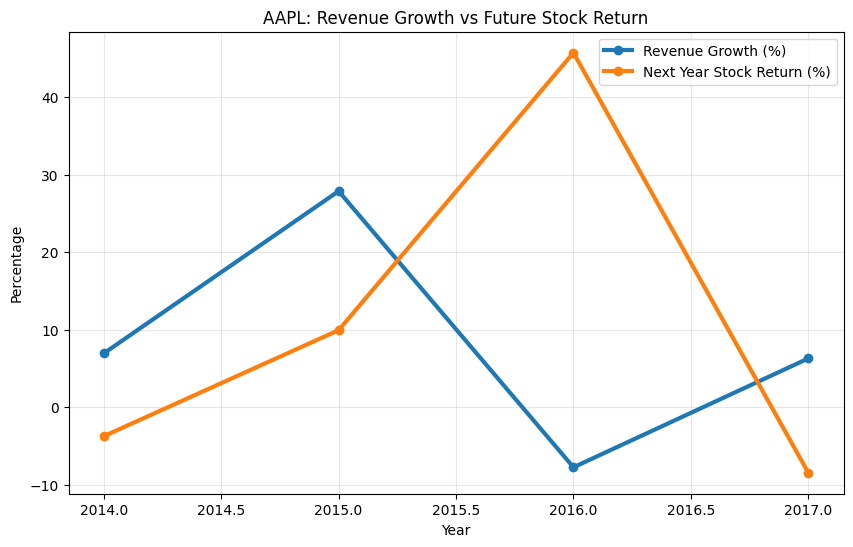

In [45]:
import matplotlib.pyplot as plt

# Filter AAPL data
aapl_data = analysis_df[
    analysis_df['symbol'] == 'AAPL'
]

# Create figure
plt.figure(figsize=(10,6))

# Revenue growth line
plt.plot(
    aapl_data['year'],
    aapl_data['revenue_growth'] * 100,
    marker='o',
    linewidth=3,
    label='Revenue Growth (%)'
)

# Future stock return line
plt.plot(
    aapl_data['year'],
    aapl_data['next_year_return'],
    marker='o',
    linewidth=3,
    label='Next Year Stock Return (%)'
)

# Labels
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.title("AAPL: Revenue Growth vs Future Stock Return")

# Legend
plt.legend()

# Grid
plt.grid(alpha=0.3)

plt.show()

In [46]:
"""
Insight:
The analysis suggests that stock markets do not always react
immediately to financial growth.

In several cases, strong revenue growth did not lead to
strong future stock returns.

Similarly, some periods with weaker financial growth
were followed by strong market performance.

This indicates that investor sentiment, market expectations,
and external factors influence stock prices alongside
company fundamentals.
"""

'\nInsight:\nThe analysis suggests that stock markets do not always react\nimmediately to financial growth.\n\nIn several cases, strong revenue growth did not lead to\nstrong future stock returns.\n\nSimilarly, some periods with weaker financial growth\nwere followed by strong market performance.\n\nThis indicates that investor sentiment, market expectations,\nand external factors influence stock prices alongside\ncompany fundamentals.\n'

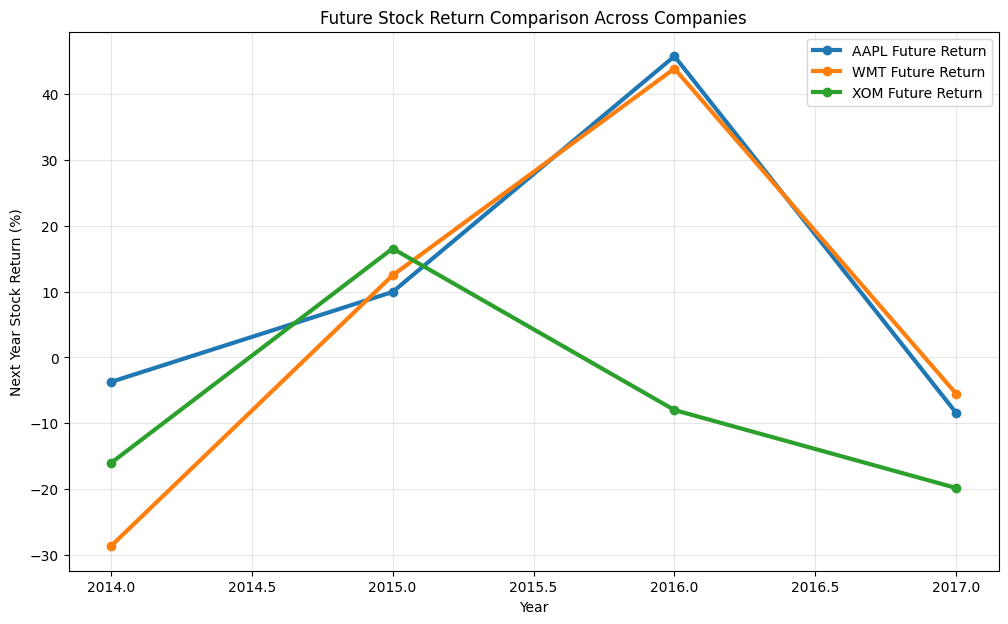

In [47]:
import matplotlib.pyplot as plt

# Companies to compare
companies = ['AAPL', 'WMT', 'XOM']

# Create figure
plt.figure(figsize=(12,7))

# Loop through each company
for company in companies:
    
    # Filter company data
    company_data = analysis_df[
        analysis_df['symbol'] == company
    ]
    
    # Plot future stock return
    plt.plot(
        company_data['year'],
        company_data['next_year_return'],
        marker='o',
        linewidth=3,
        label=f'{company} Future Return'
    )

# Labels
plt.xlabel("Year")
plt.ylabel("Next Year Stock Return (%)")

plt.title("Future Stock Return Comparison Across Companies")

# Legend
plt.legend()

# Grid
plt.grid(alpha=0.3)

plt.show()

In [48]:
# Company performance summary
company_consistency = analysis_df.groupby('symbol')[
    'return_pct'
].agg(['mean', 'std'])

company_consistency.head()

,mean,std
symbol,,
AAPL,22.900957,23.653402
AMX,-3.126050,28.554160
BP,-1.898263,20.479652
MCK,0.680717,23.854227
PTR,-7.460567,23.660016


In [49]:
# Rename columns
company_consistency.columns = [
    'avg_return',
    'volatility'
]

company_consistency.head()

,avg_return,volatility
symbol,,
AAPL,22.900957,23.653402
AMX,-3.126050,28.554160
BP,-1.898263,20.479652
MCK,0.680717,23.854227
PTR,-7.460567,23.660016


In [50]:
# Sort by average return
company_consistency = company_consistency.sort_values(
    by='avg_return',
    ascending=False
)

company_consistency

,avg_return,volatility
symbol,,
AAPL,22.900957,23.653402
WMT,9.120730,29.672296
TM,1.422911,5.086502
MCK,0.680717,23.854227
SNP,-0.096702,19.235685
BP,-1.898263,20.479652
AMX,-3.126050,28.554160
XOM,-3.699904,14.052648
PTR,-7.460567,23.660016


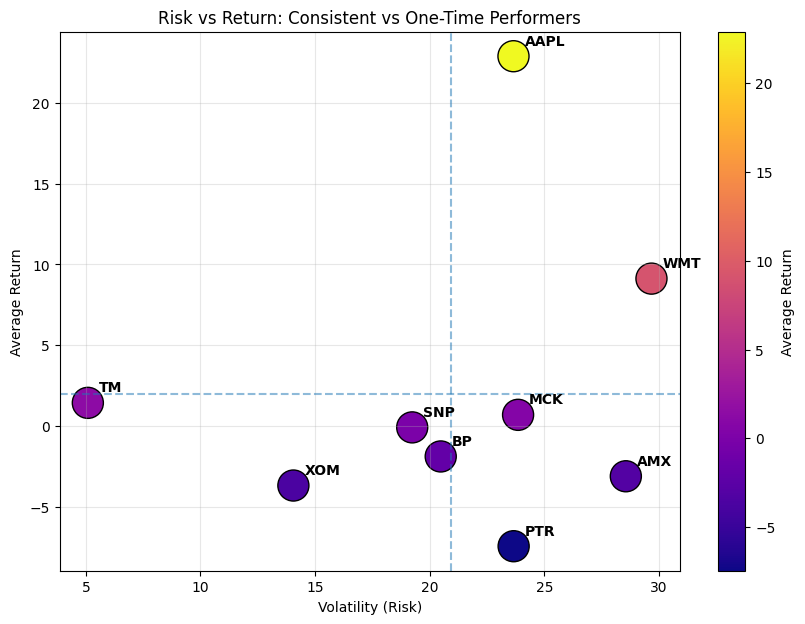

In [51]:

plt.figure(figsize=(10,7))

# Scatter plot
scatter = plt.scatter(
    company_consistency['volatility'],
    company_consistency['avg_return'],
    
    s=500,
    
    c=company_consistency['avg_return'],   # color based on return
    cmap='plasma',
    
    edgecolors='black'
)

# Labels
for company in company_consistency.index:
    
    plt.annotate(
        company,
        
        (
            company_consistency.loc[company, 'volatility'],
            company_consistency.loc[company, 'avg_return']
        ),
        
        textcoords="offset points",
        xytext=(8,8),
        fontsize=10,
        fontweight='bold'
    )

# Average reference lines
plt.axhline(
    company_consistency['avg_return'].mean(),
    linestyle='--',
    alpha=0.5
)

plt.axvline(
    company_consistency['volatility'].mean(),
    linestyle='--',
    alpha=0.5
)

# Labels
plt.xlabel("Volatility (Risk)")
plt.ylabel("Average Return")

plt.title("Risk vs Return: Consistent vs One-Time Performers")

# Color bar
plt.colorbar(
    scatter,
    label='Average Return'
)

# Grid
plt.grid(alpha=0.3)

plt.show()

In [52]:
"""
Insight:
The analysis showed clear differences between stable performers
and highly volatile companies.

AAPL emerged as the strongest performer with high average returns,
while companies like PTR and AMX showed weaker returns
combined with higher volatility.

This suggests that some companies delivered more consistent
long-term performance, whereas others depended on unstable
or short-term market movements.
"""

'\nInsight:\nThe analysis showed clear differences between stable performers\nand highly volatile companies.\n\nAAPL emerged as the strongest performer with high average returns,\nwhile companies like PTR and AMX showed weaker returns\ncombined with higher volatility.\n\nThis suggests that some companies delivered more consistent\nlong-term performance, whereas others depended on unstable\nor short-term market movements.\n'

In [53]:
# Sector performance summary
sector_risk_return = merged_df.groupby('sector')[
    'return_pct'
].agg(['mean', 'std'])

sector_risk_return.head()

,mean,std
sector,,
Communication Services,-6.196492,25.664043
Consumer Cyclical,-0.776448,6.602293
Consumer Defensive,6.193024,26.517752
Energy,-5.237016,16.463675
Healthcare,-5.559829,24.929705


In [54]:
# Rename columns
sector_risk_return.columns = [
    'avg_return',
    'volatility'
]

sector_risk_return.head()


,avg_return,volatility
sector,,
Communication Services,-6.196492,25.664043
Consumer Cyclical,-0.776448,6.602293
Consumer Defensive,6.193024,26.517752
Energy,-5.237016,16.463675
Healthcare,-5.559829,24.929705


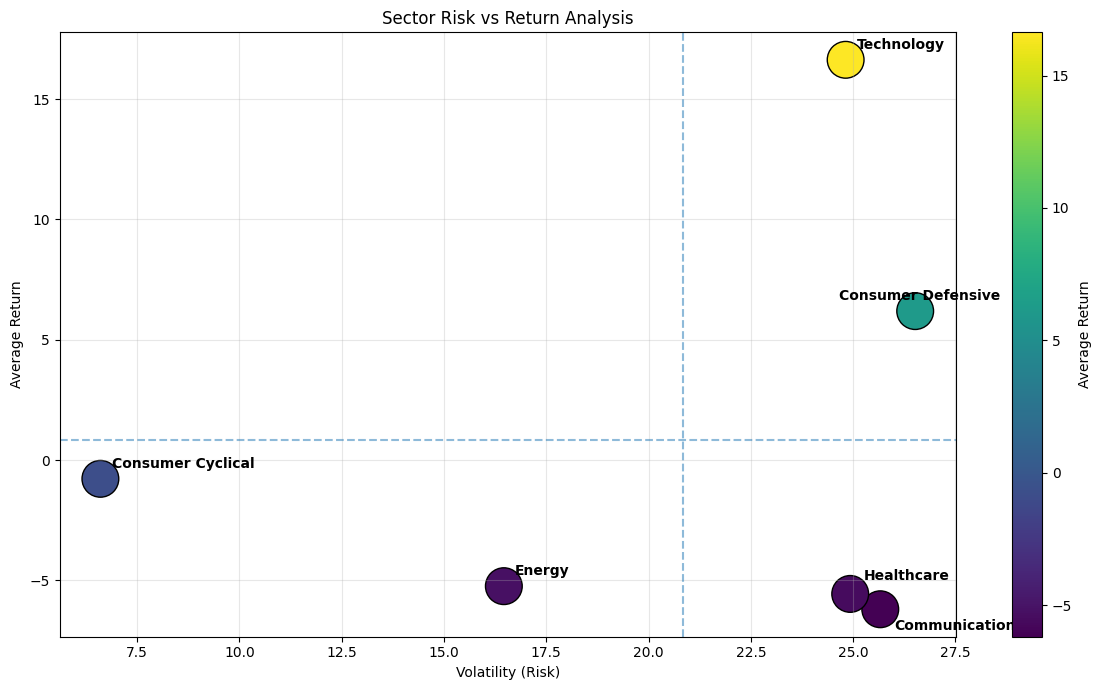

In [55]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12,7))

# Scatter plot
scatter = plt.scatter(
    sector_risk_return['volatility'],
    sector_risk_return['avg_return'],
    
    s=700,
    
    c=sector_risk_return['avg_return'],
    
    cmap='viridis',
    
    edgecolors='black'
)

# Labels
for sector in sector_risk_return.index:
    
    x = sector_risk_return.loc[sector, 'volatility']
    y = sector_risk_return.loc[sector, 'avg_return']
    
    # Short label for cleaner chart
    label = sector
    
    if sector == 'Communication Services':
        label = 'Communication'
    
    # Custom positions
    if sector == 'Healthcare':
        
        plt.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(10, 10),
            fontsize=10,
            fontweight='bold'
        )
        
    elif sector == 'Consumer Defensive':
        
        plt.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(-55, 8),   # move left
            
            fontsize=10,
            fontweight='bold'
        )
        
    elif sector == 'Communication Services':
        
        plt.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(10, -15),
            fontsize=10,
            fontweight='bold'
        )
        
    else:
        
        plt.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(8,8),
            fontsize=10,
            fontweight='bold'
        )

# Average reference lines
plt.axhline(
    sector_risk_return['avg_return'].mean(),
    linestyle='--',
    alpha=0.5
)

plt.axvline(
    sector_risk_return['volatility'].mean(),
    linestyle='--',
    alpha=0.5
)

# Axis labels
plt.xlabel("Volatility (Risk)")
plt.ylabel("Average Return")

# Title
plt.title("Sector Risk vs Return Analysis")

# Color bar
plt.colorbar(
    scatter,
    label='Average Return'
)

# Grid
plt.grid(alpha=0.3)

# Auto layout
plt.tight_layout()

# Show chart
plt.show()

In [56]:
"""
Insight:
The analysis highlighted clear differences in the
risk-return trade-offs across sectors.

Technology emerged as the strongest performing sector,
delivering the highest average returns despite moderate risk levels.

Consumer Defensive showed a more balanced and stable profile,
offering decent returns with comparatively controlled volatility.

On the other hand, sectors like Healthcare and Communication Services
experienced weaker returns along with higher volatility,
making them less attractive from a risk-return perspective.

This suggests that higher risk does not always guarantee
higher returns, and some sectors provide a more efficient
balance between stability and performance.
"""

'\nInsight:\nThe analysis highlighted clear differences in the\nrisk-return trade-offs across sectors.\n\nTechnology emerged as the strongest performing sector,\ndelivering the highest average returns despite moderate risk levels.\n\nConsumer Defensive showed a more balanced and stable profile,\noffering decent returns with comparatively controlled volatility.\n\nOn the other hand, sectors like Healthcare and Communication Services\nexperienced weaker returns along with higher volatility,\nmaking them less attractive from a risk-return perspective.\n\nThis suggests that higher risk does not always guarantee\nhigher returns, and some sectors provide a more efficient\nbalance between stability and performance.\n'

In [57]:
# Company investment summary
investment_df = analysis_df.groupby('symbol').agg({
    
    'return_pct': ['mean', 'std'],
    
    'revenue_growth': 'mean'
})

investment_df.head()

return_pct            revenue_growth
             mean        std           mean
symbol                                     
AAPL    22.900957  23.653402       0.083450
AMX     -3.126050  28.554160      -0.007725
BP      -1.898263  20.479652      -0.082050
MCK      0.680717  23.854227       0.133450
PTR     -7.460567  23.660016      -0.026025

In [58]:
# Rename columns
investment_df.columns = [
    
    'avg_return',
    
    'volatility',
    
    'avg_revenue_growth'
]

investment_df.head()

,avg_return,volatility,avg_revenue_growth
symbol,,,
AAPL,22.900957,23.653402,0.083450
AMX,-3.126050,28.554160,-0.007725
BP,-1.898263,20.479652,-0.082050
MCK,0.680717,23.854227,0.133450
PTR,-7.460567,23.660016,-0.026025


In [59]:
# Investment score
investment_df['investment_score'] = (
    
    investment_df['avg_return'] +
    
    (investment_df['avg_revenue_growth'] * 100)
    
    - investment_df['volatility']
)

investment_df.head()

,avg_return,volatility,avg_revenue_growth,investment_score
symbol,,,,
AAPL,22.900957,23.653402,0.083450,7.592555
AMX,-3.126050,28.554160,-0.007725,-32.452710
BP,-1.898263,20.479652,-0.082050,-30.582915
MCK,0.680717,23.854227,0.133450,-9.828511
PTR,-7.460567,23.660016,-0.026025,-33.723082


In [60]:
# Investment score
investment_df['investment_score'] = (
    
    investment_df['avg_return'] +
    
    (investment_df['avg_revenue_growth'] * 100)
    
    - investment_df['volatility']
)

investment_df.head(10)

,avg_return,volatility,avg_revenue_growth,investment_score
symbol,,,,
AAPL,22.900957,23.653402,0.083450,7.592555
AMX,-3.126050,28.554160,-0.007725,-32.452710
BP,-1.898263,20.479652,-0.082050,-30.582915
MCK,0.680717,23.854227,0.133450,-9.828511
PTR,-7.460567,23.660016,-0.026025,-33.723082
SNP,-0.096702,19.235685,-0.045125,-23.844886
TM,1.422911,5.086502,0.018500,-1.813591
WMT,9.120730,29.672296,0.009100,-19.641567
XOM,-3.699904,14.052648,-0.111425,-28.895053


In [61]:
# Best investment candidates
investment_df = investment_df.sort_values(
    
    by='investment_score',
    
    ascending=False
)

investment_df

,avg_return,volatility,avg_revenue_growth,investment_score
symbol,,,,
AAPL,22.900957,23.653402,0.083450,7.592555
TM,1.422911,5.086502,0.018500,-1.813591
MCK,0.680717,23.854227,0.133450,-9.828511
WMT,9.120730,29.672296,0.009100,-19.641567
SNP,-0.096702,19.235685,-0.045125,-23.844886
XOM,-3.699904,14.052648,-0.111425,-28.895053
BP,-1.898263,20.479652,-0.082050,-30.582915
AMX,-3.126050,28.554160,-0.007725,-32.452710
PTR,-7.460567,23.660016,-0.026025,-33.723082


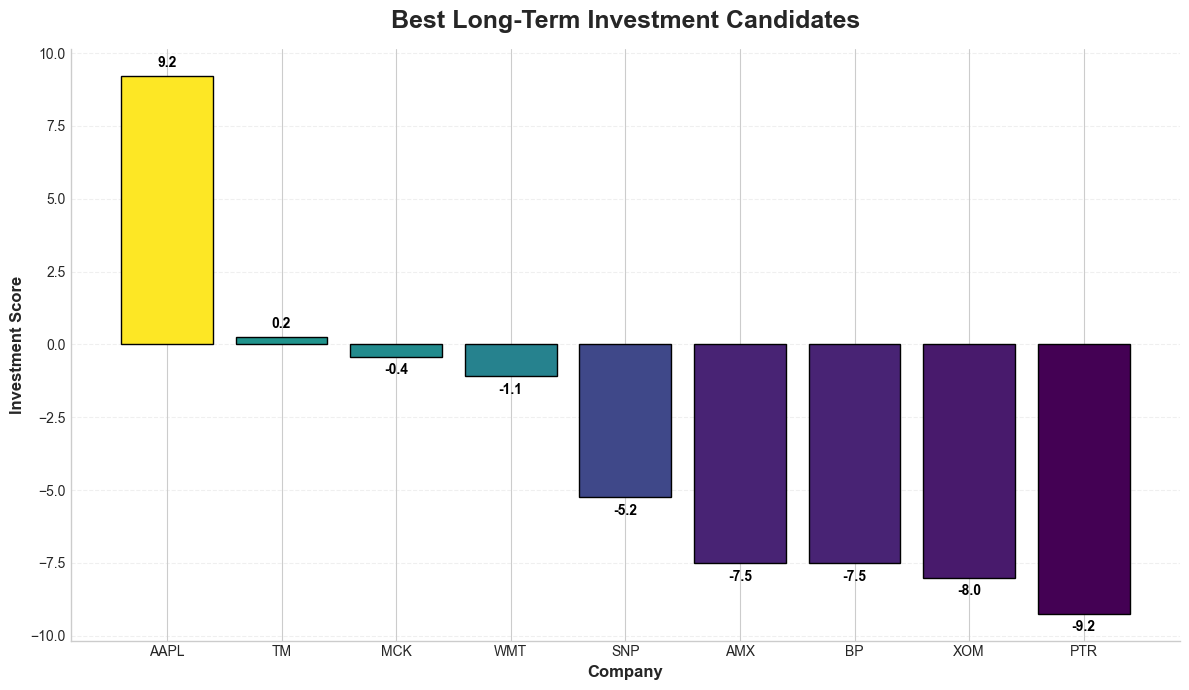

In [62]:
import matplotlib.pyplot as plt

# Company investment summary
investment_df = analysis_df.groupby('symbol').agg({
    
    'return_pct': ['mean', 'std'],
    
    'revenue_growth': 'mean'
})

# Rename columns
investment_df.columns = [
    
    'avg_return',
    
    'volatility',
    
    'avg_revenue_growth'
]

# Better balanced investment score
investment_df['investment_score'] = (
    
    (investment_df['avg_return'] * 0.5)
    
    +
    
    (investment_df['avg_revenue_growth'] * 100 * 0.3)
    
    -
    
    (investment_df['volatility'] * 0.2)
)

# Sort companies
investment_df = investment_df.sort_values(
    
    by='investment_score',
    
    ascending=False
)

# Figure style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure
plt.figure(figsize=(12,7))

# Bar chart
bars = plt.bar(
    
    investment_df.index,
    
    investment_df['investment_score'],
    
    color=plt.cm.viridis(
        (
            investment_df['investment_score']
            -
            investment_df['investment_score'].min()
        )
        /
        (
            investment_df['investment_score'].max()
            -
            investment_df['investment_score'].min()
        )
    ),
    
    edgecolor='black'
)

# Labels
plt.xlabel(
    "Company",
    
    fontsize=12,
    
    fontweight='bold'
)

plt.ylabel(
    "Investment Score",
    
    fontsize=12,
    
    fontweight='bold'
)

# Title
plt.title(
    "Best Long-Term Investment Candidates",
    
    fontsize=18,
    
    fontweight='bold',
    
    pad=15
)

# Grid
plt.grid(
    axis='y',
    
    linestyle='--',
    
    alpha=0.3
)

# Add values on bars
for bar in bars:
    
    height = bar.get_height()
    
    # Position for positive/negative bars
    if height >= 0:
        
        y_position = height + 0.3
        
    else:
        
        y_position = height - 0.6
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        
        y_position,
        
        f'{height:.1f}',
        
        ha='center',
        
        fontsize=10,
        
        fontweight='bold',
        
        color='black'
    )
# Remove top/right borders
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Layout
plt.tight_layout()

# Show chart
plt.show()

In [63]:
"""
Insight:
The investment score analysis helped identify companies
with stronger long-term investment potential by combining
returns, financial growth, and volatility into a single metric.

AAPL emerged as the strongest long-term investment candidate,
showing the highest investment score due to its strong returns
and consistent financial growth.

TM demonstrated a comparatively stable profile with moderate performance,
while companies such as PTR, XOM, and BP received weaker scores
because of lower returns and higher volatility.

This analysis suggests that successful long-term investments
depend not only on returns, but also on balancing growth and risk effectively.
"""

'\nInsight:\nThe investment score analysis helped identify companies\nwith stronger long-term investment potential by combining\nreturns, financial growth, and volatility into a single metric.\n\nAAPL emerged as the strongest long-term investment candidate,\nshowing the highest investment score due to its strong returns\nand consistent financial growth.\n\nTM demonstrated a comparatively stable profile with moderate performance,\nwhile companies such as PTR, XOM, and BP received weaker scores\nbecause of lower returns and higher volatility.\n\nThis analysis suggests that successful long-term investments\ndepend not only on returns, but also on balancing growth and risk effectively.\n'

In [64]:
# Average yearly market return
market_trend = analysis_df.groupby('year')[
    'return_pct'
].mean()

market_trend

year
2014     6.269126
2015   -19.370841
2016     6.078462
2017    14.953844
Name: return_pct, dtype: float64

In [65]:
# Weak market years
weak_years = market_trend[
    market_trend < 0
].index

weak_years

Index([2015], dtype='int64', name='year')

In [66]:
# Data during weak years
crisis_df = analysis_df[
    analysis_df['year'].isin(weak_years)
]

crisis_df.head()

,symbol,year,revenue_growth,return_pct,next_year_return
17,AAPL,2015,0.2786,-3.722674,9.938302
12,AMX,2015,0.0000,-35.237213,-9.176304
14,BP,2015,-0.3700,-17.995800,20.347720
10,MCK,2015,0.3032,-4.811777,-27.852264
16,PTR,2015,-0.2788,-40.588772,14.316730


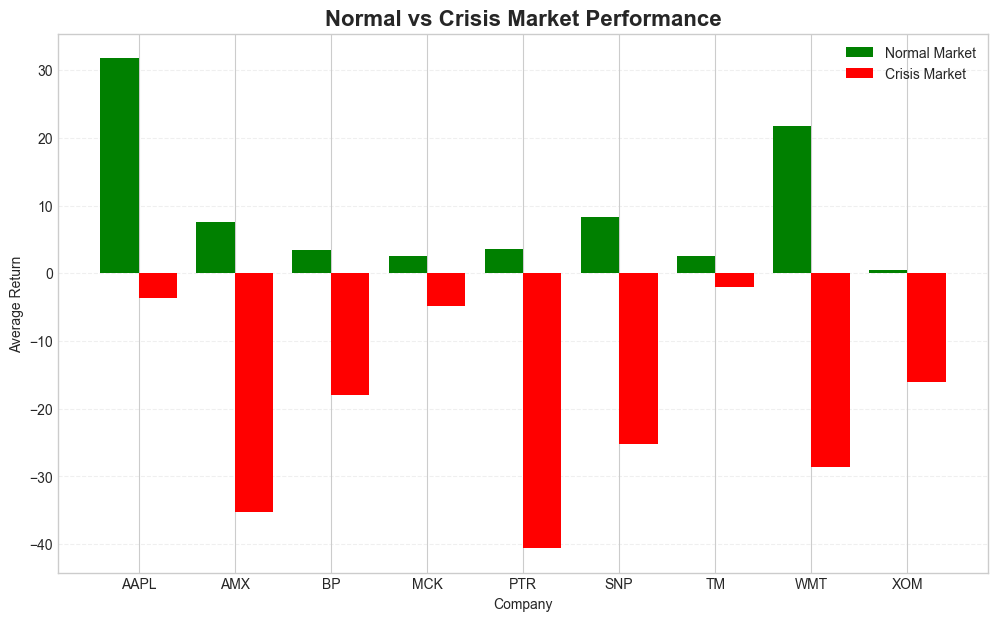

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Normal years
normal_df = analysis_df[
    ~analysis_df['year'].isin(weak_years)
]

# Average returns
normal_returns = normal_df.groupby('symbol')[
    'return_pct'
].mean()

crisis_returns = crisis_df.groupby('symbol')[
    'return_pct'
].mean()

# Combine
comparison_df = pd.DataFrame({
    
    'Normal Market': normal_returns,
    
    'Crisis Market': crisis_returns
})

# Figure
plt.figure(figsize=(12,7))

x = np.arange(len(comparison_df.index))

# Bars
plt.bar(
    x - 0.2,
    
    comparison_df['Normal Market'],
    
    width=0.4,
    
    color='green',
    
    label='Normal Market'
)

plt.bar(
    x + 0.2,
    
    comparison_df['Crisis Market'],
    
    width=0.4,
    
    color='red',
    
    label='Crisis Market'
)

# Labels
plt.xticks(
    x,
    
    comparison_df.index
)

# Title
plt.title(
    "Normal vs Crisis Market Performance",
    
    fontsize=16,
    
    fontweight='bold'
)

# Labels
plt.xlabel("Company")
plt.ylabel("Average Return")

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Legend
plt.legend()

plt.show()

In [68]:
"""
Insight:
The comparison between normal and crisis market performance
revealed a significant decline in stock returns during weak market periods.

AAPL experienced an approximate decline of nearly 35%,
while companies such as PTR and AMX showed much larger drops
of around 44% and 43% respectively during crisis conditions.

TM and MCK demonstrated relatively smaller declines,
with performance drops of nearly 4% to 7%,
indicating stronger resilience during market downturns.

The analysis suggests that market sentiment and panic selling
can heavily impact stock performance during crises,
even for fundamentally strong companies.
"""

'\nInsight:\nThe comparison between normal and crisis market performance\nrevealed a significant decline in stock returns during weak market periods.\n\nAAPL experienced an approximate decline of nearly 35%,\nwhile companies such as PTR and AMX showed much larger drops\nof around 44% and 43% respectively during crisis conditions.\n\nTM and MCK demonstrated relatively smaller declines,\nwith performance drops of nearly 4% to 7%,\nindicating stronger resilience during market downturns.\n\nThe analysis suggests that market sentiment and panic selling\ncan heavily impact stock performance during crises,\neven for fundamentally strong companies.\n'

In [73]:
# Empty dataframe to store all company data
all_stock_data = pd.DataFrame()

In [83]:
# Combine stock data of all companies

for company in valid_companies:
    
    # Read company stock data
    temp = pd.read_csv(f"stocks/{company}.csv")
    
    # Lowercase columns
    temp.columns = temp.columns.str.lower()
    
    # Convert date
    temp['date'] = pd.to_datetime(temp['date'])
    
    # Extract month
    temp['month'] = temp['date'].dt.month
    
    # Add company name
    temp['symbol'] = company
    
    # Append data
    all_stock_data = pd.concat(
        [all_stock_data, temp],
        
        ignore_index=True
    )

all_stock_data.head(90000)

,date,open,high,low,close,adj close,volume,month,symbol
0,1972-08-25,0.063477,0.064697,0.063477,0.064453,0.023442,2508800.0,8,WMT
1,1972-08-28,0.064453,0.064941,0.064209,0.064209,0.023353,972800.0,8,WMT
2,1972-08-29,0.063965,0.063965,0.063477,0.063477,0.023087,1945600.0,8,WMT
3,1972-08-30,0.063477,0.063477,0.062988,0.063477,0.023087,409600.0,8,WMT
4,1972-08-31,0.062988,0.062988,0.062500,0.062500,0.022732,870400.0,8,WMT
...,...,...,...,...,...,...,...,...,...
89995,2013-10-17,75.489998,76.120003,71.690002,75.779999,64.572807,6395100.0,10,WMT
89996,2013-10-18,75.800003,75.930000,75.480003,75.709999,64.513145,6788500.0,10,WMT
89997,2013-10-21,75.720001,75.820000,74.820000,75.150002,64.035965,5364100.0,10,WMT
89998,2013-10-22,75.430000,76.489998,75.209999,76.320000,65.032967,6948500.0,10,WMT


In [75]:
# Average monthly stock prices across all companies
monthly_pattern = all_stock_data.groupby('month')[
    'close'
].mean()

monthly_pattern

month
1     42.638315
2     43.097435
3     42.526210
4     42.267369
5     42.562736
6     42.457193
7     43.058669
8     42.648710
9     42.387928
10    42.777772
11    42.972529
12    42.924332
Name: close, dtype: float64

In [84]:
valid_companies

['WMT', 'SNP', 'PTR', 'XOM', 'BP', 'TM', 'AAPL', 'AMX', 'MCK']

In [85]:
# Monthly deviation from overall average
monthly_deviation = (
    monthly_pattern
    -
    monthly_pattern.mean()
)

monthly_deviation

month
1    -0.054952
2     0.404168
3    -0.167057
4    -0.425898
5    -0.130531
6    -0.236073
7     0.365403
8    -0.044557
9    -0.305338
10    0.084506
11    0.279262
12    0.231065
Name: close, dtype: float64

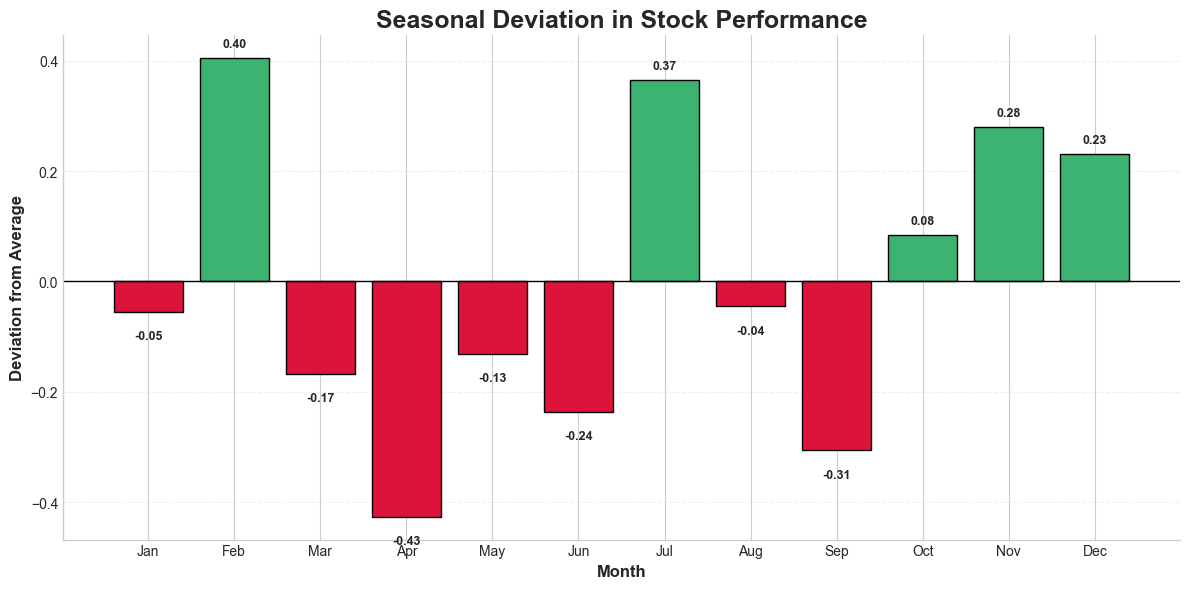

In [86]:
import matplotlib.pyplot as plt

# Figure style
plt.style.use('seaborn-v0_8-whitegrid')

# Month names
month_names = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

# Create figure
plt.figure(figsize=(12,6))

# Colors
colors = [
    'mediumseagreen' if x > 0 else 'crimson'
    for x in monthly_deviation.values
]

# Bars
bars = plt.bar(
    monthly_deviation.index,
    
    monthly_deviation.values,
    
    color=colors,
    
    edgecolor='black'
)

# Zero line
plt.axhline(
    0,
    
    color='black',
    
    linewidth=1
)

# X labels
plt.xticks(
    range(1,13),
    
    month_names
)

# Labels
plt.xlabel(
    "Month",
    
    fontsize=12,
    
    fontweight='bold'
)

plt.ylabel(
    "Deviation from Average",
    
    fontsize=12,
    
    fontweight='bold'
)

# Title
plt.title(
    "Seasonal Deviation in Stock Performance",
    
    fontsize=18,
    
    fontweight='bold'
)

# Values
for bar in bars:
    
    height = bar.get_height()
    
    y_pos = height + 0.02 if height >= 0 else height - 0.05
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        
        y_pos,
        
        f'{height:.2f}',
        
        ha='center',
        
        fontsize=9,
        
        fontweight='bold'
    )

# Grid
plt.grid(
    axis='y',
    
    linestyle='--',
    
    alpha=0.3
)

# Remove borders
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Layout
plt.tight_layout()

# Show
plt.show()

In [87]:
"""
Insight:
The seasonal analysis revealed mild variations
in stock performance across different months.

February recorded the strongest positive deviation
at approximately +0.40 above the overall average,
followed by July at nearly +0.36.

On the other hand, April showed the weakest seasonal performance
with a deviation of around -0.43,
while September also underperformed near -0.31.

These findings suggest that certain months demonstrated
slightly stronger market momentum,
although the overall seasonal differences remained relatively moderate.

This indicates that seasonality had only a limited influence
on long-term stock performance across companies.
"""

'\nInsight:\nThe seasonal analysis revealed mild variations\nin stock performance across different months.\n\nFebruary recorded the strongest positive deviation\nat approximately +0.40 above the overall average,\nfollowed by July at nearly +0.36.\n\nOn the other hand, April showed the weakest seasonal performance\nwith a deviation of around -0.43,\nwhile September also underperformed near -0.31.\n\nThese findings suggest that certain months demonstrated\nslightly stronger market momentum,\nalthough the overall seasonal differences remained relatively moderate.\n\nThis indicates that seasonality had only a limited influence\non long-term stock performance across companies.\n'

In [88]:
# Company size analysis
size_df = merged_df.groupby('symbol').agg({
    
    'revenue': 'mean',
    
    'return_pct': ['mean', 'std']
})

size_df.head()

revenue return_pct           
                mean       mean        std
symbol                                    
AAPL    2.253956e+11  16.634943  24.817881
AMX     2.129706e+11  -6.196492  25.664043
BP      2.639172e+11  -3.623378  18.150543
MCK     1.828422e+11  -5.559829  24.929705
PTR     3.025031e+11  -8.871231  20.731549

In [89]:
# Rename columns
size_df.columns = [
    
    'avg_revenue',
    
    'avg_return',
    
    'volatility'
]

size_df.head()

,avg_revenue,avg_return,volatility
symbol,,,
AAPL,2.253956e+11,16.634943,24.817881
AMX,2.129706e+11,-6.196492,25.664043
BP,2.639172e+11,-3.623378,18.150543
MCK,1.828422e+11,-5.559829,24.929705
PTR,3.025031e+11,-8.871231,20.731549


In [91]:
# Convert revenue to billions
size_df['revenue_billions'] = (
    
    size_df['avg_revenue']
    
    / 1_000_000_000
)

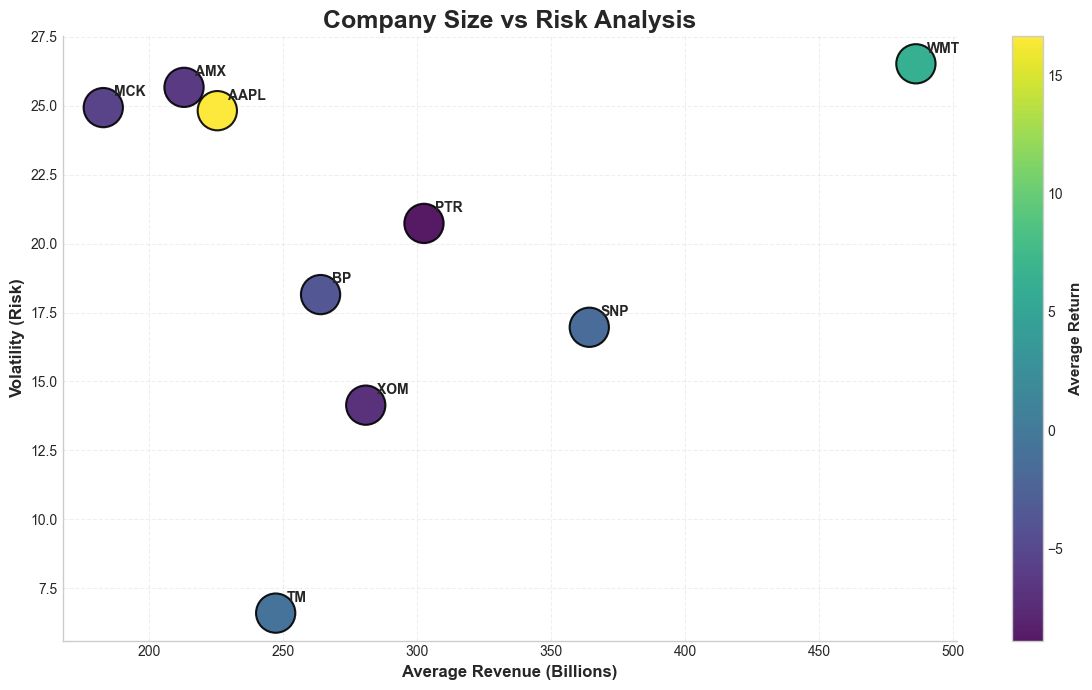

In [92]:
import matplotlib.pyplot as plt

# Figure style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure
plt.figure(figsize=(12,7))

# Scatter plot
scatter = plt.scatter(
    size_df['revenue_billions'],
    
    size_df['volatility'],
    
    s=800,
    
    c=size_df['avg_return'],
    
    cmap='viridis',
    
    edgecolors='black',
    
    linewidths=1.5,
    
    alpha=0.9
)

# Labels
for company in size_df.index:
    
    x = size_df.loc[company, 'revenue_billions']
    y = size_df.loc[company, 'volatility']
    
    plt.annotate(
        company,
        
        (x, y),
        
        textcoords="offset points",
        
        xytext=(8,8),
        
        fontsize=10,
        
        fontweight='bold'
    )

# Labels
plt.xlabel(
    "Average Revenue (Billions)",
    
    fontsize=12,
    
    fontweight='bold'
)

plt.ylabel(
    "Volatility (Risk)",
    
    fontsize=12,
    
    fontweight='bold'
)

# Title
plt.title(
    "Company Size vs Risk Analysis",
    
    fontsize=18,
    
    fontweight='bold'
)

# Color bar
cbar = plt.colorbar(scatter)

cbar.set_label(
    'Average Return',
    
    fontsize=11,
    
    fontweight='bold'
)

# Grid
plt.grid(
    alpha=0.3,
    
    linestyle='--'
)

# Remove borders
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Layout
plt.tight_layout()

# Show
plt.show()

In [1]:
!pip install streamlit